Current Bandwidth: 0.0929
STATUS: Normal Volatility.


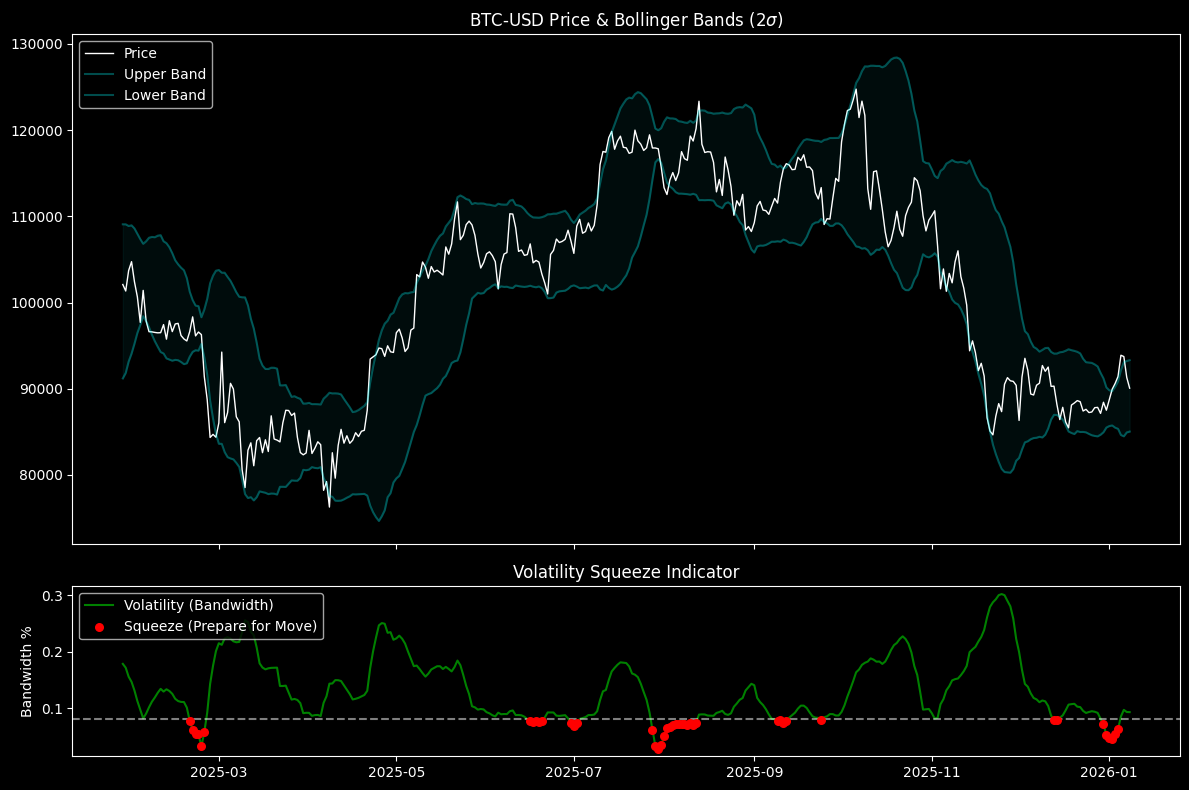

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TICKER = 'BTC-USD'    # Crypto is great for volatility strategies
LOOKBACK = 20         # Standard Bollinger Band Window
STD_DEV = 2.0         # Standard Deviation Factor
SQUEEZE_THRESH = 0.08 # Threshold for "Low Volatility" (Band Width)

def get_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d", progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    return df

def calculate_bollinger_bands(df):
    # 1. Middle Band (Simple Moving Average)
    df['SMA'] = df['Close'].rolling(window=LOOKBACK).mean()
    
    # 2. Standard Deviation
    df['std_dev'] = df['Close'].rolling(window=LOOKBACK).std()
    
    # 3. Upper and Lower Bands
    df['Upper'] = df['SMA'] + (df['std_dev'] * STD_DEV)
    df['Lower'] = df['SMA'] - (df['std_dev'] * STD_DEV)
    
    # 4. Bandwidth % (The "Squeeze" Indicator)
    # (Upper - Lower) / SMA. Low values mean volatility is dead (storm coming).
    df['Bandwidth'] = (df['Upper'] - df['Lower']) / df['SMA']
    
    return df.dropna()

def plot_squeeze(df, ticker):
    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Price & Bands
    ax1.plot(df.index, df['Close'], color='white', linewidth=1, label='Price')
    ax1.plot(df.index, df['Upper'], color='cyan', alpha=0.3, label='Upper Band')
    ax1.plot(df.index, df['Lower'], color='cyan', alpha=0.3, label='Lower Band')
    ax1.fill_between(df.index, df['Upper'], df['Lower'], color='cyan', alpha=0.05)
    ax1.set_title(f'{ticker} Price & Bollinger Bands (2$\sigma$)')
    ax1.legend(loc='upper left')

    # The Squeeze Indicator
    # We color the line RED when it drops below the threshold (The Squeeze Zone)
    squeeze_condition = df['Bandwidth'] < SQUEEZE_THRESH
    
    ax2.plot(df.index, df['Bandwidth'], color='green', label='Volatility (Bandwidth)')
    ax2.scatter(df[squeeze_condition].index, df[squeeze_condition]['Bandwidth'], 
                color='red', s=30, zorder=5, label='Squeeze (Prepare for Move)')
    
    ax2.axhline(SQUEEZE_THRESH, color='white', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Bandwidth %')
    ax2.set_title('Volatility Squeeze Indicator')
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = get_data(TICKER)
    data = calculate_bollinger_bands(data)
    
    # Check if we are in a squeeze right now
    current_bw = data['Bandwidth'].iloc[-1]
    print(f"Current Bandwidth: {current_bw:.4f}")
    
    if current_bw < SQUEEZE_THRESH:
        print("STATUS: SQUEEZE DETECTED. Expect explosive move soon.")
    else:
        print("STATUS: Normal Volatility.")
        
    plot_squeeze(data, TICKER)

Fetching BTC-USD [4h]...

--- KALMAN STATUS (BTC-USD) ---
Current Price:   $92,227.02
Projected Bias:  -0.0009% per step
Horizon Vol:     5.06% (cumulative)

--- DYNAMIC PROBABILITY MATRIX (72 Steps) ---
LEVEL      TARGET PRICE    PROBABILITY    
----------------------------------------
+3.0σ      $107,262        0.1%
+2.0σ      $101,974        2.3%
+1.5σ      $99,429        6.7%
+1.0σ      $96,948        15.9%
+0.5σ      $94,528        30.9%
-0.5σ      $89,868        30.9%
-1.0σ      $87,625        15.9%
-1.5σ      $85,438        6.7%
-2.0σ      $83,306        2.3%
-3.0σ      $79,199        0.1%


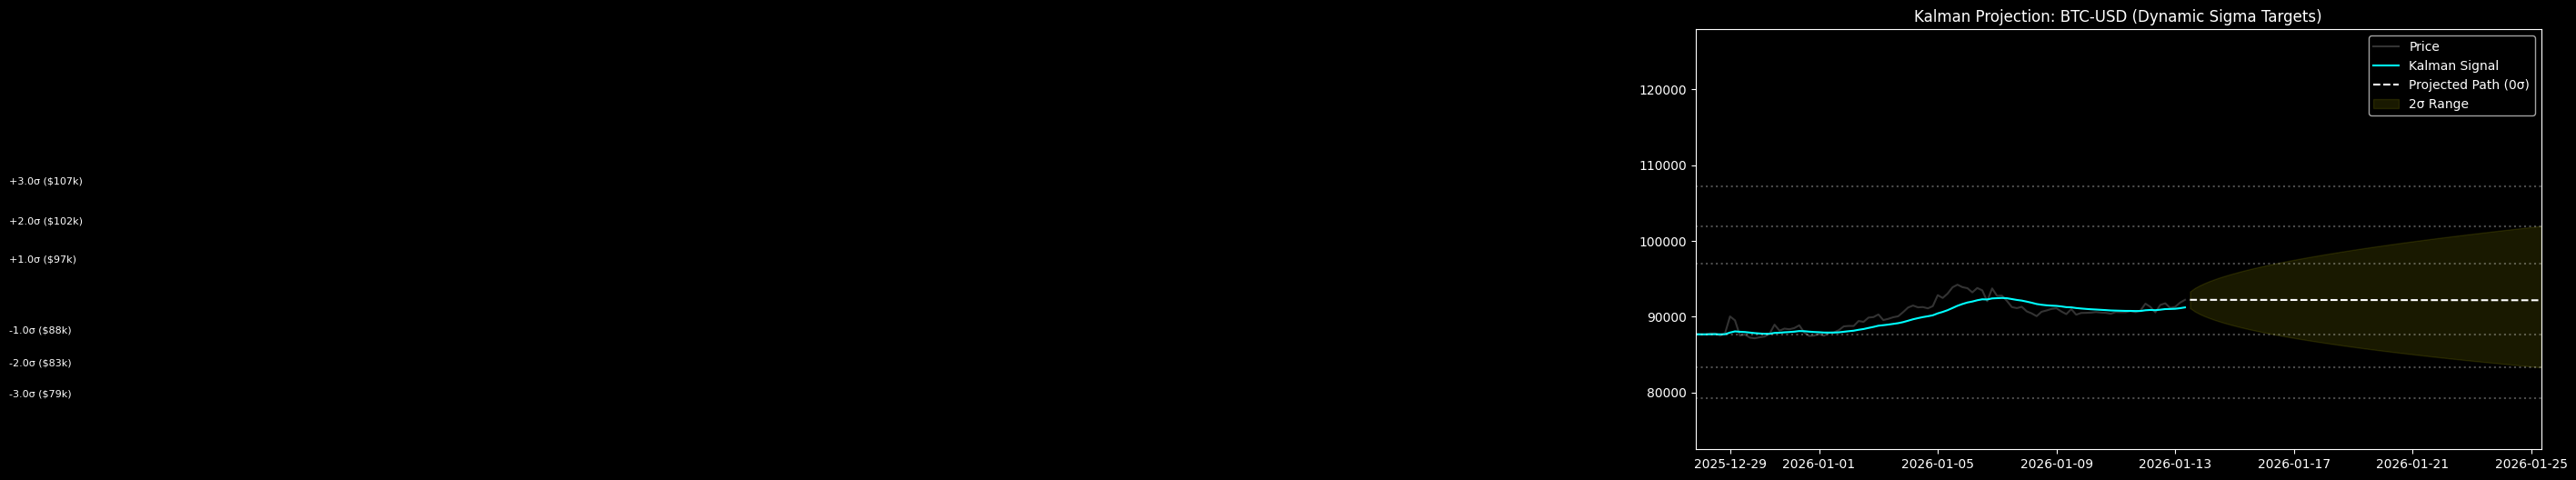

In [52]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. CONFIGURATION ---
TICKER = "BTC-USD"   
INTERVAL = "4h"       
LOOKBACK = "1y"      
HORIZON_STEPS = 72    

# Kalman Tunings
PROCESS_NOISE = 1e-3  
MEASUREMENT_NOISE = 1e-1 

# --- 2. DATA SETUP ---
freq_map = {'1m': '1min', '5m': '5min', '15m': '15min', '30m': '30min', '1h': 'h', '4h': '4h', '1d': 'D', '1wk': 'W'}
pd_freq = freq_map.get(INTERVAL, 'D')

print(f"Fetching {TICKER} [{INTERVAL}]...")
data = yf.download(TICKER, period=LOOKBACK, interval=INTERVAL, progress=False)
if data.empty: raise ValueError("No data found.")
prices = data['Close'].values.flatten()
dates = data.index

# --- 3. KALMAN FILTER ---
class KalmanFilter1D:
    def __init__(self, R, Q, initial_value):
        self.R = R  # Measurement Noise
        self.Q = Q  # Process Noise
        self.P = 1.0 
        self.x = initial_value

    def update(self, measurement):
        self.P = self.P + self.Q
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

kf = KalmanFilter1D(MEASUREMENT_NOISE, PROCESS_NOISE, prices[0])
kalman_signal = np.array([kf.update(p) for p in prices])

# --- 4. VOLATILITY & PROJECTION ---
log_returns = np.diff(np.log(prices))
step_volatility = np.std(log_returns[-50:]) # Recent volatility
current_price = prices[-1]

# Trend Slope (Drift)
trend_window = 24
slope_per_step = np.polyfit(np.arange(trend_window), kalman_signal[-trend_window:], 1)[0]
drift_pct = slope_per_step / current_price 

# Cone Calculations
future_steps = np.arange(1, HORIZON_STEPS + 1)
future_dates = pd.date_range(start=dates[-1], periods=HORIZON_STEPS + 1, freq=pd_freq)[1:]

# Expected price path (Drift)
projected_path = current_price * np.exp(drift_pct * future_steps)
# Standard Deviations (Diffusion)
sigma_t = step_volatility * np.sqrt(future_steps)

upper_cone = projected_path * np.exp(2 * sigma_t)
lower_cone = projected_path * np.exp(-2 * sigma_t)

# --- 5. DYNAMIC TARGET GENERATION ---
# We generate targets based on the FINAL projected volatility (at the last step)
final_projected_price = projected_path[-1]
final_sigma = sigma_t[-1]

# Create dynamic targets: +/- 0.5, 1.0, 1.5, 2.0, 3.0 Sigmas
sigma_levels = [3.0, 2.0, 1.5, 1.0, 0.5, -0.5, -1.0, -1.5, -2.0, -3.0]
dynamic_targets = []

for sig in sigma_levels:
    # Log-Normal Price Level = Projected * exp(Sigma * Volatility)
    price_level = final_projected_price * np.exp(sig * final_sigma)
    dynamic_targets.append({"label": f"{sig:+}σ", "price": price_level, "sigma": sig})

# --- 6. PROBABILITY ENGINE ---
def calculate_probability(target, steps, price, vol, drift):
    time_sqrt = np.sqrt(steps)
    mu_total = drift * steps
    sigma_total = vol * time_sqrt
    z_score = (np.log(target / price) - mu_total) / sigma_total
    
    if target > price:
        return (1 - norm.cdf(z_score)) * 100
    else:
        return norm.cdf(z_score) * 100

print(f"\n--- KALMAN STATUS ({TICKER}) ---")
print(f"Current Price:   ${current_price:,.2f}")
print(f"Projected Bias:  {'+' if drift_pct>0 else ''}{drift_pct*100:.4f}% per step")
print(f"Horizon Vol:     {final_sigma*100:.2f}% (cumulative)")

print(f"\n--- DYNAMIC PROBABILITY MATRIX ({HORIZON_STEPS} Steps) ---")
print(f"{'LEVEL':<10} {'TARGET PRICE':<15} {'PROBABILITY':<15}")
print("-" * 40)

for item in dynamic_targets:
    t_price = item['price']
    prob = calculate_probability(t_price, HORIZON_STEPS, current_price, step_volatility, drift_pct)
    
    # Visual check: If trend is bullish, probabilities of hitting upper levels increase
    print(f"{item['label']:<10} ${t_price:,.0f}        {prob:.1f}%")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Historical
plt.plot(dates, prices, color='gray', alpha=0.4, label='Price')
plt.plot(dates, kalman_signal, color='cyan', label='Kalman Signal')

# Projection
plt.plot(future_dates, projected_path, 'w--', label='Projected Path (0σ)')
plt.fill_between(future_dates, lower_cone, upper_cone, color='yellow', alpha=0.1, label='2σ Range')

# Plot Dynamic Targets
for item in dynamic_targets:
    if abs(item['sigma']) in [1.0, 2.0, 3.0]: # Only plot major lines to keep chart clean
        plt.axhline(item['price'], color='white', linestyle=':', alpha=0.3)
        plt.text(dates[-len(dates)//5], item['price'], f"{item['label']} (${item['price']/1000:.0f}k)", 
                 color='white', fontsize=8, verticalalignment='bottom')

plt.title(f"Kalman Projection: {TICKER} (Dynamic Sigma Targets)")
plt.xlim(dates[-100], future_dates[-1])
plt.legend()
plt.show()

--- FETCHING DATA ---

--- MACRO IMPACT ANALYSIS ---
Asset      | Corr     | Z-Score (Trend) | Impact
--------------------------------------------------
DX-Y.NYB   | -0.04    | +0.60            | -0.02
^TNX       | +0.00    | +1.07            | +0.00
^GSPC      | +0.00    | -1.01            | -0.00
--------------------------------------------------
TOTAL MACRO ADJUSTMENT: -0.0045 (Added to Drift)

--- MACRO-ADJUSTED PROBABILITIES (14 days) ---
Baseline Trend: -0.02% | Macro Effect: -0.00%
---------------------------------------------
Target +2.0σ ($97,259):  2.3%
Target +1.0σ ($96,167):  15.9%
Target +0.5σ ($95,625):  30.9%
Target -0.5σ ($94,552):  30.9%
Target -1.0σ ($94,019):  15.9%
Target -2.0σ ($92,964):  2.3%


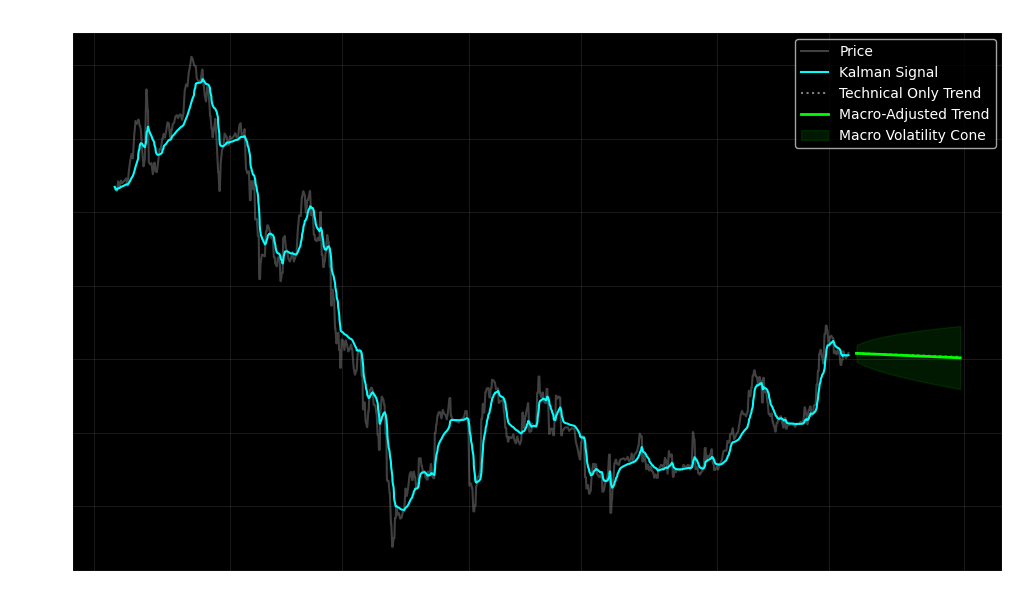

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. CONFIGURATION ---
TARGET_ASSET = "BTC-USD"
# Macro Assets to influence the probability
# DXY (Dollar), TNX (10Y Yield), GSPC (S&P 500)
MACRO_TICKERS = ["DX-Y.NYB", "^TNX", "^GSPC"] 

INTERVAL = "4h"       # Macro data is best on 1d or 1h
LOOKBACK = "3mo"      
HORIZON_STEPS = 14    # Projection length

# Kalman Tunings
PROCESS_NOISE = 1e-3  
MEASUREMENT_NOISE = 1e-1 

# --- 2. DATA FETCHER & ALIGNMENT ---
print("--- FETCHING DATA ---")
tickers_to_fetch = [TARGET_ASSET] + MACRO_TICKERS
# Download all at once to align timestamps
data = yf.download(tickers_to_fetch, period=LOOKBACK, interval=INTERVAL, group_by='ticker', progress=False)

if data.empty: raise ValueError("No data found.")

# Helper to extract Close prices safely
def get_close(ticker):
    try:
        # Handle MultiIndex if present
        if isinstance(data.columns, pd.MultiIndex):
            s = data[ticker]['Close']
        else:
            # If single ticker (fallback)
            s = data['Close']
        return s
    except KeyError:
        print(f"Warning: Could not find data for {ticker}")
        return None

# Create a clean DataFrame with all assets
df = pd.DataFrame()
df['Target'] = get_close(TARGET_ASSET)
for m in MACRO_TICKERS:
    s = get_close(m)
    if s is not None:
        df[m] = s

# FILL GAPS: Crypto trades 24/7, Macro trades Mon-Fri.
# We forward-fill macro data so weekend crypto candles have "Friday's Macro Data"
df = df.ffill().dropna()

prices = df['Target'].values
dates = df.index

# --- 3. MACRO FACTOR CALCULATION ---
# Calculate Returns
returns = np.log(df / df.shift(1)).dropna()

# 1. Calculate Correlation (Last 30 periods)
# How much does BTC care about DXY right now?
correlations = returns.corr()['Target']

# 2. Calculate Macro Trend Z-Score (Momentum)
# Is DXY pumping (+2) or dumping (-2)?
# We use a 20-period Z-Score for momentum
rolling_mean = df.rolling(window=20).mean()
rolling_std = df.rolling(window=20).std()
z_scores = (df - rolling_mean) / rolling_std
current_z = z_scores.iloc[-1]

# 3. Compute "Macro Drag"
# Drag = Sum(Correlation * Z-Score)
# Example: If DXY Z-Score is +2.0 (Super Bullish) AND Correlation is -0.5 (Inverse)
# Impact = 2.0 * -0.5 = -1.0 (Bearish Drag on BTC)
macro_drag_score = 0.0
print(f"\n--- MACRO IMPACT ANALYSIS ---")
print(f"{'Asset':<10} | {'Corr':<8} | {'Z-Score (Trend)':<15} | {'Impact'}")
print("-" * 50)

for m in MACRO_TICKERS:
    if m in df.columns:
        corr = correlations[m]
        z = current_z[m]
        impact = corr * z
        # We weight macro impact (e.g., 0.2 factor) so it doesn't overpower price action
        macro_drag_score += impact * 0.2 
        
        print(f"{m:<10} | {corr:+.2f}    | {z:+.2f}            | {impact:+.2f}")

print("-" * 50)
print(f"TOTAL MACRO ADJUSTMENT: {macro_drag_score:+.4f} (Added to Drift)")

# --- 4. KALMAN FILTER ---
class KalmanFilter1D:
    def __init__(self, R, Q, initial_value):
        self.R = R; self.Q = Q; self.P = 1.0; self.x = initial_value
    def update(self, measurement):
        self.P = self.P + self.Q
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

kf = KalmanFilter1D(MEASUREMENT_NOISE, PROCESS_NOISE, prices[0])
kalman_signal = np.array([kf.update(p) for p in prices])

# --- 5. PROJECTION (WITH MACRO ADJUSTMENT) ---
current_price = prices[-1]
# Base Drift (from Price Action)
trend_window = 14
slope = np.polyfit(np.arange(trend_window), kalman_signal[-trend_window:], 1)[0]
base_drift_pct = slope / current_price 

# FINAL DRIFT = Technical Drift + Macro Drag
# If Macro is bad, this lowers the slope.
adjusted_drift_pct = base_drift_pct + (macro_drag_score / 100) # Scaling factor

# Volatility
step_volatility = np.std(np.diff(np.log(prices))[-30:])

# Generate Paths
future_steps = np.arange(1, HORIZON_STEPS + 1)
future_dates = pd.date_range(start=dates[-1], periods=HORIZON_STEPS + 1)[1:] # Daily freq

# Path A: Pure Technicals (For comparison)
path_tech = current_price * np.exp(base_drift_pct * future_steps)
# Path B: Macro-Adjusted (The "Real" Forecast)
path_macro = current_price * np.exp(adjusted_drift_pct * future_steps)

# Cones (based on Macro path)
sigma_t = step_volatility * np.sqrt(future_steps)
upper_cone = path_macro * np.exp(2 * sigma_t)
lower_cone = path_macro * np.exp(-2 * sigma_t)

# --- 6. DYNAMIC TARGETS & PROBABILITY ---
# We calculate probability using the MACRO-ADJUSTED drift
final_sigma = sigma_t[-1]
final_price = path_macro[-1]

sigma_levels = [2.0, 1.0, 0.5, -0.5, -1.0, -2.0]
print(f"\n--- MACRO-ADJUSTED PROBABILITIES ({HORIZON_STEPS} days) ---")
print(f"Baseline Trend: {base_drift_pct*100:+.2f}% | Macro Effect: {macro_drag_score:+.2f}%")
print("-" * 45)

for sig in sigma_levels:
    target = final_price * np.exp(sig * final_sigma)
    
    # Probability Calculation
    mu_total = adjusted_drift_pct * HORIZON_STEPS
    sigma_total = step_volatility * np.sqrt(HORIZON_STEPS)
    z_score = (np.log(target / current_price) - mu_total) / sigma_total
    
    if target > current_price:
        prob = (1 - norm.cdf(z_score)) * 100
    else:
        prob = norm.cdf(z_score) * 100
        
    print(f"Target {sig:+.1f}σ (${target:,.0f}):  {prob:.1f}%")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.style.use('dark_background')

# History
plt.plot(dates, prices, color='gray', alpha=0.5, label='Price')
plt.plot(dates, kalman_signal, color='cyan', label='Kalman Signal')

# Projections
plt.plot(future_dates, path_tech, color='white', linestyle=':', alpha=0.5, label='Technical Only Trend')
plt.plot(future_dates, path_macro, color='lime', linewidth=2, label='Macro-Adjusted Trend')

# Cone
plt.fill_between(future_dates, lower_cone, upper_cone, color='lime', alpha=0.1, label='Macro Volatility Cone')

plt.title(f"Macro-Quant Model: {TARGET_ASSET} vs [DXY, Yields, SPX]")
plt.legend()
plt.grid(True, alpha=0.1)
plt.show()